# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data.csv")
print("Размер исходной таблицы:", data.shape)
print("Столбцы:", data.columns.tolist())
print(data["plans_universitypast_failures"].value_counts().sort_index())

# В заголовке потерялась запятая, поэтому два признака склеились.
# Знак кодирует plans_university, последняя цифра — past_failures:
# 10 -> (1, 0), -13 -> (-1, 3) и т. д.
broken = data.pop("plans_universitypast_failures")
data["plans_university"] = np.sign(broken).astype(int)
data["past_failures"] = broken.abs() % 10

print("После исправления:")
display(data[["plans_university", "past_failures"]].value_counts().sort_index())

Размер исходной таблицы: (649, 17)
Столбцы: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'nursery', 'plans_universitypast_failures']
plans_universitypast_failures
-13      6
-12      7
-11     20
-10     36
 10    513
 11     50
 12      9
 13      8
Name: count, dtype: int64
После исправления:


plans_university  past_failures
-1                0                 36
                  1                 20
                  2                  7
                  3                  6
 1                0                513
                  1                 50
                  2                  9
                  3                  8
Name: count, dtype: int64

### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [11]:
# Число пропусков до заполнения
missing_before = data.isnull().sum()
display(missing_before[missing_before > 0])

# Все признаки числовые, поэтому пропуски можно заменить средними столбцов.
data = data.fillna(data.mean())
print("Пропусков после заполнения:", int(data.isnull().sum().sum()))

goout     1
Dalc     10
Walc      6
dtype: int64

Пропусков после заполнения: 0


### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [12]:
from sklearn.preprocessing import StandardScaler

# Отдельно показываем нормализованную таблицу.
scaler = StandardScaler()
normalized_data = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns,
    index=data.index,
)
display(normalized_data.agg(["mean", "std"]).round(3))

# Ниже при кросс-валидации StandardScaler будет находиться внутри Pipeline.
# Это важно: на каждом фолде scaler обучается только на train-части.

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
mean,0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline

result = pd.read_csv("scores.csv", header=None, names=["score"])["score"]

cv = KFold(n_splits=4, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LinearRegression())
comparison = []

def evaluate_cv(X, y, stage):
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error"},
    )
    report = pd.DataFrame({
        "fold": np.arange(1, 5),
        "R2": scores["test_R2"],
        "RMSE": -scores["test_RMSE"],
    })
    comparison.append({
        "stage": stage,
        "mean_R2": report["R2"].mean(),
        "mean_RMSE": report["RMSE"].mean(),
    })
    print(stage)
    display(report.round(4))
    print("Среднее:", report[["R2", "RMSE"]].mean().round(4).to_dict())
    return report

baseline_report = evaluate_cv(data, result, "Исходные признаки после задач 1–3")

Исходные признаки после задач 1–3


,fold,R2,RMSE
0,1,0.1751,16.1817
1,2,0.3115,15.4210
2,3,0.2432,13.1104
3,4,0.0806,15.1889


Среднее: {'R2': 0.2026, 'RMSE': 14.9755}


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [14]:
# В attendance.csv первая строка — номера 32 занятий, '+' означает присутствие.
attendance = pd.read_csv("attendance.csv", sep=";")
classes_attended = attendance.eq("+").sum(axis=1)

# Файл содержит только индексы получателей помощи, а не 649 значений.
support_ids = np.loadtxt("school_support.txt", dtype=int)
school_support = pd.Series(0, index=data.index, dtype=int)
school_support.loc[support_ids] = 1

data_full = data.assign(
    classes_attended=classes_attended,
    school_support=school_support,
)

display(data_full[["classes_attended", "school_support"]].describe())
full_report = evaluate_cv(data_full, result, "Добавлены посещаемость и матпомощь")

,classes_attended,school_support
count,649.000000,649.000000
mean,28.340524,0.104777
std,4.640759,0.306502
min,0.000000,0.000000
25%,26.000000,0.000000
50%,30.000000,0.000000
75%,32.000000,0.000000
max,32.000000,1.000000


Добавлены посещаемость и матпомощь


,fold,R2,RMSE
0,1,0.1967,15.9684
1,2,0.3149,15.3827
2,3,0.2521,13.0335
3,4,0.0746,15.2383


Среднее: {'R2': 0.2096, 'RMSE': 14.9057}


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

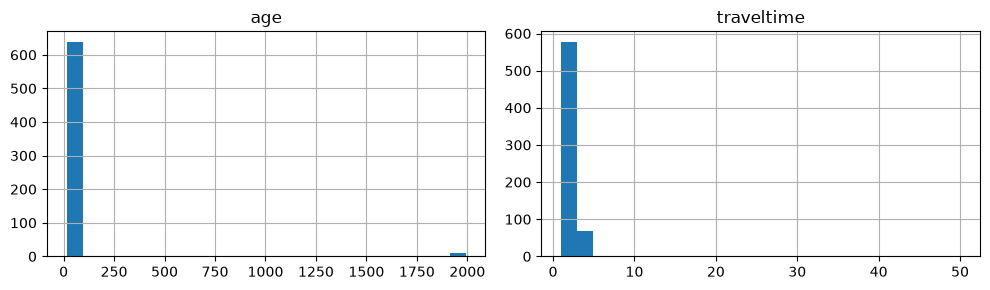

Подозрительный возраст:


,age
30,1987
71,1988
75,1989
287,1988
344,1990
435,1990
437,1988
447,1988
522,1991
548,1990


Подозрительное время в пути:


,traveltime
70,10
250,25
498,50
648,40


Исправлены age и traveltime


,fold,R2,RMSE
0,1,0.2034,15.9014
1,2,0.3155,15.3770
2,3,0.2544,13.0130
3,4,0.1046,14.9897


Среднее: {'R2': 0.2195, 'RMSE': 14.8203}


In [15]:
# Диапазоны из условия позволяют увидеть неправдоподобные значения.
data_full[["age", "traveltime"]].hist(bins=25, figsize=(10, 3))
plt.tight_layout()
plt.show()

print("Подозрительный возраст:")
display(data_full.loc[data_full["age"] > 100, ["age"]])
print("Подозрительное время в пути:")
display(data_full.loc[data_full["traveltime"] > 4, ["traveltime"]])

data_clean = data_full.copy()

# Вместо возраста в нескольких строках записан год рождения.
birth_year_mask = data_clean["age"] > 100
data_clean.loc[birth_year_mask, "age"] = 2006 - data_clean.loc[birth_year_mask, "age"]

# Вместо категории в четырёх строках записано число минут.
travel_mask = data_clean["traveltime"] > 4
data_clean.loc[travel_mask, "traveltime"] = pd.cut(
    data_clean.loc[travel_mask, "traveltime"],
    bins=[-np.inf, 15, 30, 60, np.inf],
    labels=[1, 2, 3, 4],
    right=False,
).astype(int)

features_clean_report = evaluate_cv(
    data_clean, result, "Исправлены age и traveltime"
)

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

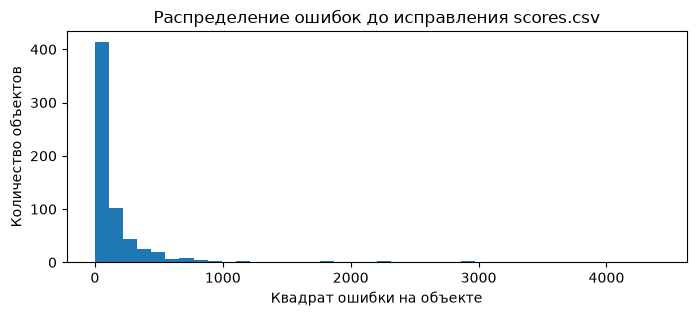

,score,prediction,squared_error
354,0.00,66.388,4407.383
585,0.70,65.913,4252.717
615,0.00,62.627,3922.137
385,0.00,61.189,3744.128
319,0.00,59.047,3486.600
303,0.00,56.342,3174.458
257,0.55,55.932,3067.167
462,0.00,53.938,2909.344
404,0.55,54.364,2895.909
423,0.00,53.777,2891.915


In [16]:
from sklearn.metrics import mean_squared_error

# Модель на всей выборке нужна здесь только для диагностического графика.
regression = make_pipeline(StandardScaler(), LinearRegression()).fit(data_clean, result)
prediction = regression.predict(data_clean)
errors = (prediction - result.to_numpy()) ** 2

plt.figure(figsize=(8, 3))
plt.hist(errors, bins=40)
plt.xlabel("Квадрат ошибки на объекте")
plt.ylabel("Количество объектов")
plt.title("Распределение ошибок до исправления scores.csv")
plt.show()

largest_errors = pd.DataFrame({
    "score": result,
    "prediction": prediction,
    "squared_error": errors,
}).nlargest(20, "squared_error")
display(largest_errors.round(3))

,old_score,fixed_score
196,0.35,35.0
231,0.50,50.0
257,0.55,55.0
404,0.55,55.0
585,0.70,70.0


Исправлены также ошибочные оценки


,fold,R2,RMSE
0,1,0.2631,13.6490
1,2,0.3209,14.4354
2,3,0.2626,12.9416
3,4,0.1130,14.9187


Среднее: {'R2': 0.2399, 'RMSE': 13.9862}


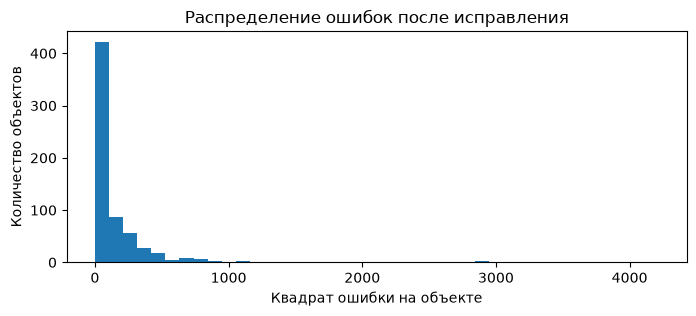

In [17]:
# Нулевые оценки допустимы, поэтому удалять строки с большой ошибкой нельзя.
# Но положительные дроби меньше 1 выбиваются из 5-балльного шага процентов:
# это доли, которые забыли умножить на 100.
suspicious_scores = (result > 0) & (result < 1)
display(pd.DataFrame({
    "old_score": result[suspicious_scores],
    "fixed_score": (result[suspicious_scores] * 100).round(),
}))

result_clean = result.copy()
result_clean.loc[suspicious_scores] = (result_clean.loc[suspicious_scores] * 100).round()

final_report = evaluate_cv(
    data_clean, result_clean, "Исправлены также ошибочные оценки"
)

# Проверим распределение ошибок после исправления.
final_regression = make_pipeline(StandardScaler(), LinearRegression()).fit(
    data_clean, result_clean
)
final_prediction = final_regression.predict(data_clean)
final_errors = (final_prediction - result_clean.to_numpy()) ** 2

plt.figure(figsize=(8, 3))
plt.hist(final_errors, bins=40)
plt.xlabel("Квадрат ошибки на объекте")
plt.ylabel("Количество объектов")
plt.title("Распределение ошибок после исправления")
plt.show()

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

In [18]:
summary = pd.DataFrame(comparison).set_index("stage")
display(summary.round(4))

base_r2 = summary.iloc[0]["mean_R2"]
final_r2 = summary.iloc[-1]["mean_R2"]
base_rmse = summary.iloc[0]["mean_RMSE"]
final_rmse = summary.iloc[-1]["mean_RMSE"]

print(f"Средний R²: {base_r2:.3f} -> {final_r2:.3f}")
print(f"Средний RMSE: {base_rmse:.3f} -> {final_rmse:.3f}")
print(f"Прирост R²: {final_r2 - base_r2:+.3f}")
print(f"Снижение RMSE: {base_rmse - final_rmse:+.3f}")

print("""
Выводы:
1. В data.csv были склеены plans_university и past_failures; после разделения
   модель получила два осмысленных признака.
2. Нормализация почти не должна менять предсказания обычной линейной регрессии,
   но полезна для сопоставимого масштаба признаков и выполнена без утечки данных.
3. Посещаемость и материальная помощь дали небольшой прирост среднего R².
4. В age встречались годы рождения, в traveltime — минуты вместо категорий,
   а пять оценок были долями вместо процентов. Их восстановили, а не удалили.
5. После всех исправлений средний R² вырос, а RMSE уменьшился. Разброс между
   фолдами остаётся заметным: простая линейная модель объясняет лишь часть
   различий в итоговых оценках.
""")

,mean_R2,mean_RMSE
stage,,
Исходные признаки после задач 1–3,0.2026,14.9755
Добавлены посещаемость и матпомощь,0.2096,14.9057
Исправлены age и traveltime,0.2195,14.8203
Исправлены также ошибочные оценки,0.2399,13.9862


Средний R²: 0.203 -> 0.240
Средний RMSE: 14.976 -> 13.986
Прирост R²: +0.037
Снижение RMSE: +0.989

Выводы:
1. В data.csv были склеены plans_university и past_failures; после разделения
   модель получила два осмысленных признака.
2. Нормализация почти не должна менять предсказания обычной линейной регрессии,
   но полезна для сопоставимого масштаба признаков и выполнена без утечки данных.
3. Посещаемость и материальная помощь дали небольшой прирост среднего R².
4. В age встречались годы рождения, в traveltime — минуты вместо категорий,
   а пять оценок были долями вместо процентов. Их восстановили, а не удалили.
5. После всех исправлений средний R² вырос, а RMSE уменьшился. Разброс между
   фолдами остаётся заметным: простая линейная модель объясняет лишь часть
   различий в итоговых оценках.

